# Homework 6 Code File

In [6]:
import arviz as az
import pandas as pd
import numpy as np
import pymc as pm
from pymc.math import exp
import matplotlib.pyplot as plt
import pytensor.tensor.subtensor as st
from itertools import combinations


## Question 1

In [7]:
mice_data = pd.read_csv("data/mice.csv")
mice_data.head()

,weeks,censored,group
0,12.0,0.0,Irradiated Control
1,1.0,0.0,Irradiated Control
2,21.0,0.0,Irradiated Control
3,25.0,0.0,Irradiated Control
4,11.0,0.0,Irradiated Control


In [8]:
mice_data[mice_data["censored"] != 0].head()

,weeks,censored,group
17,NaN,40.0,Irradiated Control
25,NaN,40.0,Vehicle Control
26,NaN,40.0,Vehicle Control
30,NaN,40.0,Vehicle Control
32,NaN,40.0,Vehicle Control


In [9]:
y = mice_data["weeks"].copy()
censored = mice_data["censored"].copy()
y[np.isnan(y)] = censored[np.isnan(y)]
censored[censored == 0] = np.inf

# convert group labels to integer indices
group_idx = mice_data["group"].astype("category").cat.codes.values
group_names = mice_data["group"].astype("category").cat.categories.values

In [10]:
group_idx

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int8)

In [11]:
def contrasts(var, index):
    """Calculate differences between levels with names like "alpha[low] - alpha[high]".

    var: pytensor.tensor.var.TensorVariable
    index: pandas.Index
    """
    name = var.name
    for i, j in combinations(range(index.size), 2):
        a, b = index[i], index[j]
        pm.Deterministic(f"{name}[{a}] - {name}[{b}]", var[i] - var[j])

In [ ]:
# Model Weibull survival data with right censoring (as censored poinsts are indicated by missing values in weeks variables, and upper limit in censored variable)
with pm.Model() as model:
    alpha = pm.Gamma("alpha", alpha=1, beta=1)
    beta = pm.Normal("beta", mu=0, sigma=1, shape=4)
    # Scale parameter lambda for each group
    beta_prime = pm.Deterministic("beta_prime", 1/(pm.math.exp(beta[group_idx])))

    # Define the likelihood for uncensored data
    obs_latent = pm.Weibull.dist(alpha=alpha, beta=beta_prime)
    # Define the likelihood for censored data
    obs_censored = pm.Censored(
        "censored", obs_latent, lower=None, upper=censored, observed=y
        )

    # Compute median survival times for each group
    median_survival = pm.Deterministic(
        "median_survival", pm.math.exp(-beta) * np.log(2) ** (1 / alpha)
        )
    S = pm.Deterministic("survival", pm.math.exp(-((obs_censored / beta_prime) ** alpha)))
    pdf = (
        (alpha / beta_prime) * ((obs_censored / beta_prime) ** (alpha - 1)) * pm.math.exp(-((obs_censored / beta_prime) ** alpha))
    )
    pm.Deterministic("hazard", pdf / S)

    # Calculate contrasts between groups
    contrasts(beta, group_names)

    trace_1 = pm.sample(10000, tune=2000, nuts_sampler="nutpie")

az.summary(trace_1, var_names=["group_level_lambda", "median_survival"], round_to=3, hdi_prob=0.95)     

d:\anaconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,12000,0,0.88,3
,12000,0,0.86,3
,12000,0,0.93,3
,12000,0,0.85,3


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
group_level_lambda[0],26.141,2.214,21.852,30.542,0.010,0.011,46649.367,31357.845,1.0
group_level_lambda[1],23.603,2.080,19.764,27.882,0.010,0.011,47426.431,31551.113,1.0
group_level_lambda[2],28.686,2.628,23.815,34.041,0.013,0.014,44998.995,30529.025,1.0
group_level_lambda[3],38.617,3.860,31.688,46.587,0.018,0.022,49357.805,29817.929,1.0
median_survival[0],22.859,2.016,18.911,26.872,0.010,0.010,43160.090,30894.271,1.0
median_survival[1],20.637,1.856,17.160,24.435,0.009,0.010,45218.342,31267.361,1.0
median_survival[2],25.082,2.358,20.566,29.794,0.011,0.012,42779.397,31122.313,1.0
median_survival[3],33.758,3.375,27.167,40.276,0.016,0.019,49425.211,29682.955,1.0


[Text(0, 0.0, 'Irradiated Control'),
 Text(0, 0.825, 'Positive Control'),
 Text(0, 1.65, 'Test Substance'),
 Text(0, 2.4749999999999996, 'Vehicle Control')]

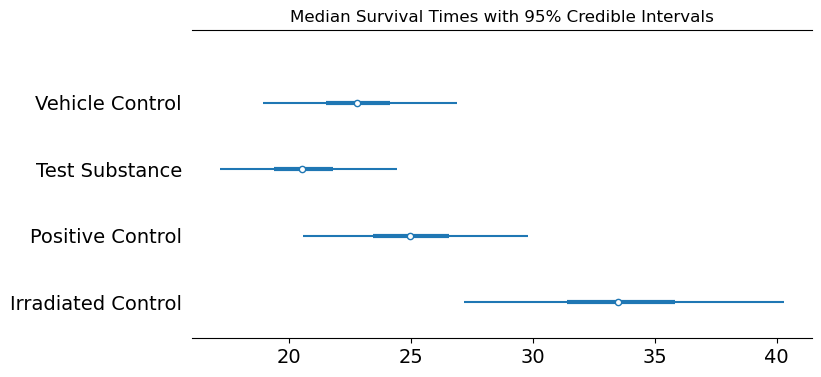

In [13]:
# Plot median survival times with 95% credible intervals
ax = az.plot_forest(
    trace_1,
    var_names=["median_survival"],
    combined=True,
    hdi_prob=0.95,
    figsize=(8, 4),
)
ax[0].set_title("Median Survival Times with 95% Credible Intervals")
ax[0].set_yticklabels(group_names)

In [16]:
# Summarise and plot contrasts between group 4 (irradiated) and other groups
contrast_names = [f"beta[{group_names[i]}] - beta[{group_names[3]}]" for i in range(3)]
contrast_summary = az.summary(trace_1, var_names=contrast_names, round_to=3, hdi_prob=0.95)
contrast_summary


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[Irradiated Control] - beta[Vehicle Control],-0.389,0.130,-0.647,-0.136,0.001,0.001,47247.279,30071.520,1.0
beta[Positive Control] - beta[Vehicle Control],-0.491,0.133,-0.761,-0.237,0.001,0.001,47721.883,30989.823,1.0
beta[Test Substance] - beta[Vehicle Control],-0.297,0.134,-0.557,-0.026,0.001,0.001,45556.964,30510.488,1.0


Text(0.5, 0, 'Difference in Beta Coefficients')

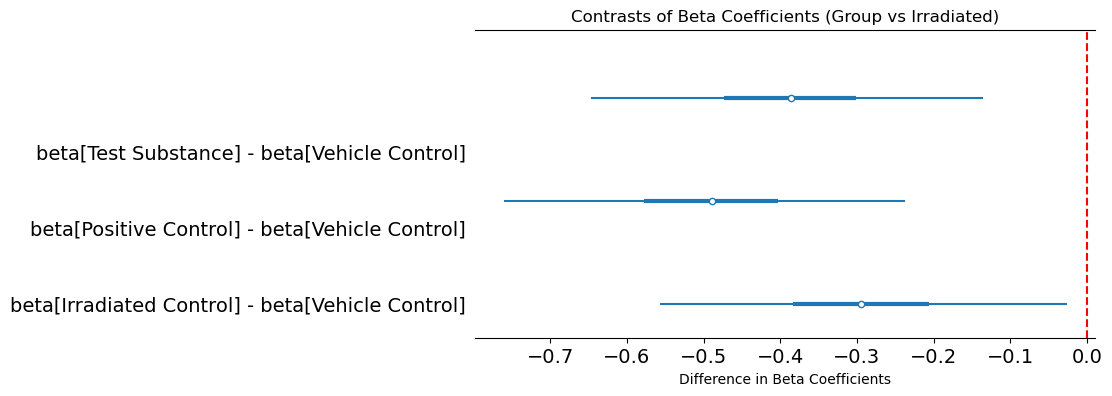

In [21]:
az.plot_forest(
    trace_1,
    var_names=contrast_names,
    combined=True,
    hdi_prob=0.95,
    figsize=(8, 4),
)
plt.title("Contrasts of Beta Coefficients (Group vs Irradiated)")
plt.yticks(ticks=range(3), labels=contrast_names)
# Add vertical line at zero for reference
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Difference in Beta Coefficients")